In [1]:
import os
import scanpy as sc
from scipy import sparse
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import math
import squidpy as sq
from utils import (
    GO_KEGG
)

analyze_all = 1

dataset_name = 'mouse_brain_coronal'  #mouse_brain_coronal Cerebellum-PLATO Intestinal-villi
use_gene_emb = 'scGPT+ESM+pubmedbert' # 'scGPT+ESM+pubmedbert'

figure_path = "figures_" + dataset_name + '_' + use_gene_emb +'/'
os.makedirs(figure_path, exist_ok=True)

if dataset_name == 'mouse_brain_coronal':
    base_spot_size = 1   
if dataset_name == 'Intestinal-villi':
    base_spot_size = 1 
if dataset_name == 'Cerebellum-PLATO':
    base_spot_size = 40   
    
adata_raw = sc.read_h5ad(figure_path+"adata_with_predict.h5ad")
adata_raw.layers['X'] = adata_raw.X.copy()
adata_raw.X = adata_raw.layers['GT'].copy()
print(adata_raw)

adata_with_predict = adata_raw.copy()
adata_with_predict.var_names = adata_with_predict.var['gene_name']
adata_with_predict.X = adata_with_predict.layers['predict']

adata_predict = sc.read_h5ad(figure_path+"adata_predict_union.h5ad") # adata_predict_union adata_predict_intersection
print(adata_predict)

/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 208 × 4351
    obs: 'X', 'Y'
    var: 'gene', 'genes', 'gene_name'
    uns: 'test_gene_idx', 'train_gene_idx'
    obsm: 'spatial'
    varm: 'gate', 'gene_emb'
    layers: 'GT', 'predict', 'X'
AnnData object with n_obs × n_vars = 208 × 17230
    var: 'gene_name', 'uniprot_id', 'moranI'
    uns: 'moranI', 'spatial_neighbors'
    obsm: 'spatial'
    varm: 'gate'
    obsp: 'spatial_connectivities', 'spatial_distances'


/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/anndata/_core/anndata.py:844: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['CUL4B', 'ARFGEF2', 'TANC2', 'FAM171A2', 'CHD5']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "var")


/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/tmp/ipykernel_19982/1801407946.py:41: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added=key_added)


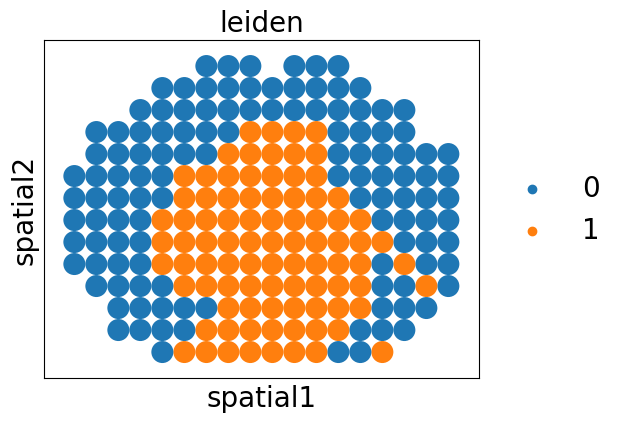

AnnData object with n_obs × n_vars = 208 × 17230
    obs: 'leiden'
    var: 'gene_name', 'uniprot_id', 'moranI'
    uns: 'moranI', 'spatial_neighbors'
    obsm: 'spatial'
    varm: 'gate'
    obsp: 'spatial_connectivities', 'spatial_distances'


In [2]:
plt.rcParams.update({
    "font.size": 20,           
    "axes.titlesize": 20,      
    "axes.labelsize": 20,     
    "xtick.labelsize": 20,      
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.titlesize": 20,
    "figure.autolayout": True,
})


def cluster(adata_in, use_layer=None, resolution=0.1, filter_moranI=False): # 0.1
    adata = adata_in.copy()
    
    if use_layer is None:
        key_added = 'leiden'
    else:
        adata.X = adata.layers[use_layer]
        key_added = "leiden_" + use_layer
        
    if filter_moranI:
        if 'moranI' not in adata.var:
            import squidpy as sq
            sq.gr.spatial_neighbors(adata)
            sq.gr.spatial_autocorr(adata, mode="moran", n_perms=1000)
            adata.var['moranI'] = adata.var_names.map(adata.uns["moranI"]['I'])
            adata.var['moranI'] = adata.var['moranI'].fillna(0)
        top_genes = (
            adata.var["moranI"]
            .sort_values(ascending=False)
            .head(2000)
            .index
        )
        adata = adata[:, top_genes]

    sc.tl.pca(adata, n_comps=50)

    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=15)

    sc.tl.leiden(adata, resolution=resolution, key_added=key_added)

    sc.pl.spatial(
                adata,
                color=key_added,
                spot_size=base_spot_size,
                cmap="tab20",
                img_key=None)
    adata_in.obs[key_added] = adata.obs[key_added]
    return adata_in


adata_predict = cluster(adata_predict, filter_moranI=True)
print(adata_predict)


In [3]:
sc.tl.rank_genes_groups(
    adata_predict,
    groupby='leiden',   
    method='wilcoxon',          
    use_raw=False              
)

cluster_top_dict = {}
for group in adata_predict.obs['leiden'].cat.categories:
    cluster_genes = sc.get.rank_genes_groups_df(adata_predict, group=group)
    cluster_top = cluster_genes.sort_values('scores', ascending=False)
    cluster_top_dict[group] = cluster_top   

/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/share/home/lijc/.conda/envs/SPgen_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [4]:
topk = 200
bg = list(adata_predict.var['gene_name'])
for group in cluster_top_dict.keys():
    cluster_top = cluster_top_dict[group]
    cluster_top_p = cluster_top['names'].values[:topk]
    cluster_top_g = (adata_predict.var.loc[cluster_top_p, 'gene_name'].values)

    GO_KEGG(gene_list=list(cluster_top_g), background=bg, figure_path=figure_path, save_name='testall_union_cluster_'+group+'_top'+str(topk), organism='mouse')

    sc.pl.spatial(adata_predict, color=cluster_top_p[:25], ncols=5, spot_size=base_spot_size, cmap="plasma", vmin="p2", vmax="p98", img_key=None, show=False)
    fig = plt.gcf()
    for ax in fig.axes:
        ax.set_yticks([])       
        ax.set_yticklabels([])  
        ax.set_ylabel('')  

        ax.tick_params(axis='both', labelsize=25)
        # 标题字体
        title = ax.get_title()
        ax.set_title(title, fontsize=30)
        # 去掉横纵坐标名字
        ax.set_xlabel("")
        # 去掉方框（top/right/left/bottom spine）
        for spine in ax.spines.values():
            spine.set_visible(False)       
    plt.savefig(figure_path+'/Enrichr_testall_union_cluster_'+group+'_top'+str(topk)+'/genes.png', dpi=100, bbox_inches='tight')
    plt.close()


/share/home/lijc/.local/lib/python3.9/site-packages/gseapy/plot.py:1351: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  dot.fig.savefig(ofname, bbox_inches="tight", dpi=300)


Figure saved to figures_mouse_brain_coronal_scGPT+ESM+pubmedbert/Enrichr_testall_union_cluster_0_top200/GO_Biological_Process_2021.mouse.enrichr.png


/tmp/ipykernel_19982/1751462313.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(figure_path+'/Enrichr_testall_union_cluster_'+group+'_top'+str(topk)+'/genes.png', dpi=100, bbox_inches='tight')
/share/home/lijc/.local/lib/python3.9/site-packages/gseapy/plot.py:1351: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  dot.fig.savefig(ofname, bbox_inches="tight", dpi=300)


Figure saved to figures_mouse_brain_coronal_scGPT+ESM+pubmedbert/Enrichr_testall_union_cluster_1_top200/GO_Biological_Process_2021.mouse.enrichr.png


/tmp/ipykernel_19982/1751462313.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(figure_path+'/Enrichr_testall_union_cluster_'+group+'_top'+str(topk)+'/genes.png', dpi=100, bbox_inches='tight')
